# Library imports

In [130]:
import os
import time
from typing import List, Tuple

import torch
import numpy as np
import cv2
import onnxruntime as ort
# from qai_appbuilder import QNNContext, PerfProfile, Runtime, LogLevel, ProfilingLevel, QNNConfig
# from qai_hub_models.models.face_det_lite.utils import detect as _face_det_decode
from sklearn.metrics import mean_squared_error, accuracy_score
import tqdm

# Dataset load

In [131]:
# DATA_DIR = "/home/ubuntu/AgeDB"
DATA_DIR = "data/"
img_paths = [os.path.join(DATA_DIR, img) for img in os.listdir(DATA_DIR) if img.endswith('.jpg')][:500]
# age_labels = [int(img.split('_')[-2]) for img in img_paths]
# gender_labels = [0 if img.split('_')[-1].split('.')[0] == 'f' else 1 for img in img_paths]
age_labels = [int(img.split('/')[-1].split('_')[0]) for img in img_paths]
gender_labels = [0 if img.split('_')[-1].lower() == 'f' else 1 for img in img_paths]

In [132]:
len(img_paths), len(age_labels), len(gender_labels)

(8, 8, 8)

In [133]:
def preprocess(img, target_size=(224, 224)):
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    # img = np.transpose(img, (2, 0, 1))  # HWC to CHW
    return img[np.newaxis, :]  # Add batch dimension

In [134]:
def postprocess_age(output) -> int:
    indices = np.arange(0, 101)
    return int(np.sum(output[0] * indices))


def postprocess_gender(output) -> int:
    return int(np.argmax(output[0]))

In [135]:
FACE_DET_MODEL_NAME = "face_det_lite"
FACE_DET_MODEL_PATH = f"models/{FACE_DET_MODEL_NAME}.bin"


FACE_DET_INPUT_H = 480
FACE_DET_INPUT_W = 640
FACE_DET_STRIDE = 8
FACE_DET_FMAP_H = FACE_DET_INPUT_H // FACE_DET_STRIDE   # 60
FACE_DET_FMAP_W = FACE_DET_INPUT_W // FACE_DET_STRIDE   # 80
FACE_DET_SCORE_THRESHOLD = 0.55
FACE_DET_NMS_IOU = 0.3

# class FaceDetQNN(QNNContext):
#     def Inference(self, input_data):
#         return super().Inference([input_data])
    
# def bursted_inference(qnn, nhwc: np.ndarray):
#     PerfProfile.SetPerfProfileGlobal(PerfProfile.BURST)
#     try:
#         return qnn.Inference(nhwc)
#     finally:
#         PerfProfile.RelPerfProfileGlobal()

In [136]:
face_det_onnx = True
if face_det_onnx:
    FACE_DET_MODEL_PATH = "models/face_det_lite-onnx-w8a8/face_det_lite.onnx"
    providers_avail = ort.get_all_providers()
    print(providers_avail)
    ort_session = ort.InferenceSession(FACE_DET_MODEL_PATH, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    input_names = [i.name for i in ort_session.get_inputs()]
    output_names = [o.name for o in ort_session.get_outputs()]
    input_types = [i.type for i in ort_session.get_inputs()]
    output_types = [i.type for i in ort_session.get_outputs()]

    print('INPUT: ',  input_names, ", ", input_types)
    print('OUTPUT: ', output_names, ", ", output_types)

['NvTensorRTRTXExecutionProvider', 'TensorrtExecutionProvider', 'CUDAExecutionProvider', 'MIGraphXExecutionProvider', 'OpenVINOExecutionProvider', 'DnnlExecutionProvider', 'VitisAIExecutionProvider', 'QNNExecutionProvider', 'NnapiExecutionProvider', 'VSINPUExecutionProvider', 'JsExecutionProvider', 'CoreMLExecutionProvider', 'ArmNNExecutionProvider', 'ACLExecutionProvider', 'DmlExecutionProvider', 'RknpuExecutionProvider', 'WebNNExecutionProvider', 'WebGpuExecutionProvider', 'XnnpackExecutionProvider', 'CANNExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
INPUT:  ['input'] ,  ['tensor(uint8)']
OUTPUT:  ['heatmap', 'bbox', 'landmark'] ,  ['tensor(uint8)', 'tensor(uint8)', 'tensor(uint8)']


2026-06-15 09:55:44.885518901 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 55 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


In [137]:
class _BBox:
    __slots__ = ("x", "y", "r", "b", "score", "landmark")

    def __init__(self, xyrb, score, landmark):
        x, y, r, b = xyrb
        self.x, self.y, self.r, self.b = min(x, r), min(y, b), max(x, r), max(y, b)
        self.score = score
        self.landmark = landmark

    @property
    def box(self):
        return [self.x, self.y, self.r, self.b]

def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def _maxpool3x3(hm: np.ndarray) -> np.ndarray:
    """3x3 max pool, stride 1, pad 1 -- matches F.max_pool2d(hm, 3, 1, 1)."""
    padded = np.pad(hm, 1, mode="constant", constant_values=-np.inf)
    h, w = hm.shape
    out = np.full_like(hm, -np.inf)
    for dy in range(3):
        for dx in range(3):
            out = np.maximum(out, padded[dy : dy + h, dx : dx + w])
    return out

def _iou(a: np.ndarray, b: np.ndarray) -> float:
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0



def _nms(objs: List[_BBox], iou: float) -> List[_BBox]:
    if iou == -1 or objs is None or len(objs) <= 1:
        return objs
    objs = sorted(objs, key=lambda o: o.score, reverse=True)
    keep: List[_BBox] = []
    flags = [0] * len(objs)
    for i, obj in enumerate(objs):
        if flags[i]:
            continue
        keep.append(obj)
        for j in range(i + 1, len(objs)):
            if flags[j] == 0 and _iou(np.array(obj.box), np.array(objs[j].box)) > iou:
                flags[j] = 1
    return keep


def _nms(objs: List[_BBox], iou: float) -> List[_BBox]:
    if iou == -1 or objs is None or len(objs) <= 1:
        return objs
    objs = sorted(objs, key=lambda o: o.score, reverse=True)
    keep: List[_BBox] = []
    flags = [0] * len(objs)
    for i, obj in enumerate(objs):
        if flags[i]:
            continue
        keep.append(obj)
        for j in range(i + 1, len(objs)):
            if flags[j] == 0 and _iou(np.array(obj.box), np.array(objs[j].box)) > iou:
                flags[j] = 1
    return keep


def _decode(
    hm: np.ndarray,
    box: np.ndarray,
    landmark: np.ndarray,
    threshold: float,
    nms_iou: float,
    stride: int,
) -> List[_BBox]:
    """Reimplements qai_hub face_det_lite detect() in numpy.

    hm:       (1, 1, H, W)
    box:      (1, 4, H, W)
    landmark: (1, 10, H, W)
    """
    hm = _sigmoid(hm)[0, 0]  # (H, W)
    hmp = _maxpool3x3(hm)
    peak = ((hm == hmp).astype(np.float32) * hm).ravel()

    h, w = hm.shape
    k = min(peak.size, 2000)
    top = np.argpartition(peak, -k)[-k:]
    top = top[np.argsort(peak[top])[::-1]]  # descending by score

    objs: List[_BBox] = []
    for idx in top:
        score = float(peak[idx])
        if score < threshold:
            break
        cy, cx = divmod(int(idx), w)
        x, y, r, b = box[0, :, cy, cx]
        xyrb = ((np.array([cx, cy, cx, cy]) + [-x, -y, r, b]) * stride).tolist()
        x5y5 = landmark[0, :, cy, cx]
        x5y5 = (x5y5 + ([cx] * 5 + [cy] * 5)) * stride
        lm = list(zip(x5y5[:5], x5y5[5:]))
        objs.append(_BBox(xyrb, score, lm))

    return _nms(objs, nms_iou)

In [138]:
import json

def _load_face_quant(model_path: str) -> dict:
    meta_path = os.path.join(os.path.dirname(model_path), "metadata.json")
    with open(meta_path) as f:
        meta = json.load(f)
    spec = meta["model_files"][os.path.basename(model_path)]
    return {
        name: (o["quantization_parameters"]["scale"], o["quantization_parameters"]["zero_point"])
        for name, o in spec["outputs"].items()
        if "quantization_parameters" in o
    }

_FACE_QUANT = _load_face_quant(FACE_DET_MODEL_PATH)
print("face quant params:", _FACE_QUANT)


def _dequant(arr: np.ndarray, name: str) -> np.ndarray:
    if arr.dtype != np.uint8:
        return arr.astype(np.float32)
    scale, zp = _FACE_QUANT[name]
    return (arr.astype(np.float32) - zp) * scale


def run_face_detect(
    image_bgr: np.ndarray, qnn, debug: bool = False
) -> List[Tuple[List[float], float, List[Tuple[float, float]]]]:
    """Detect faces on a full BGR frame.

    Returns a list of (xyxy, score, landmark5) in original-image coordinates.
    Uses letterbox resize (single scale + center pad) so the detector sees
    undistorted faces regardless of input aspect ratio.
    """
    orig_h, orig_w = image_bgr.shape[:2]
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Letterbox: one scale so both dims fit, then center-pad to 640x480
    scale = min(FACE_DET_INPUT_W / orig_w, FACE_DET_INPUT_H / orig_h)
    new_w = max(1, int(round(orig_w * scale)))
    new_h = max(1, int(round(orig_h * scale)))
    pad_x = (FACE_DET_INPUT_W - new_w) // 2
    pad_y = (FACE_DET_INPUT_H - new_h) // 2
    canvas = np.zeros((FACE_DET_INPUT_H, FACE_DET_INPUT_W), dtype=gray.dtype)
    canvas[pad_y : pad_y + new_h, pad_x : pad_x + new_w] = cv2.resize(
        gray, (new_w, new_h), interpolation=cv2.INTER_LINEAR
    )

    if face_det_onnx:
        nchw = np.ascontiguousarray(canvas[None, None, ...])  # [1, 1, 480, 640] uint8
        out = ort_session.run(None, {input_names[0]: nchw})
    else:
        nhwc = np.ascontiguousarray(
            (canvas.astype(np.float32) / 255.0)[None, ..., None]
        )
        out = bursted_inference(qnn, nhwc)

    # w8a8 ONNX: dequantize each output with its own (scale, zero_point)
    hm = _dequant(out[0], "heatmap").reshape(1, 1, FACE_DET_FMAP_H, FACE_DET_FMAP_W)
    bx = _dequant(out[1], "bbox").reshape(1, 4, FACE_DET_FMAP_H, FACE_DET_FMAP_W)
    lm = _dequant(out[2], "landmark").reshape(1, 10, FACE_DET_FMAP_H, FACE_DET_FMAP_W)

    if debug:
        hm_sig = 1.0 / (1.0 + np.exp(-hm[0, 0]))
        top5 = np.sort(hm_sig.ravel())[::-1][:5]
        print(f"  image size   : {orig_w}x{orig_h}  letterbox scale={scale:.3f}  pad=({pad_x},{pad_y})")
        print(f"  output dtype : {out[0].dtype}")
        print(f"  heatmap dq   : min={hm[0,0].min():.2f}  max={hm[0,0].max():.2f}")
        print(f"  heatmap sig  : top-5 scores = {[round(s, 3) for s in top5.tolist()]}")
        print(f"  threshold    : {FACE_DET_SCORE_THRESHOLD}")

    dets = _decode(
        hm, bx, lm,
        threshold=FACE_DET_SCORE_THRESHOLD,
        nms_iou=FACE_DET_NMS_IOU,
        stride=FACE_DET_STRIDE,
    )

    if debug:
        print(f"  detections after NMS: {len(dets)}")

    # Undo letterbox: subtract pad offset, divide by scale
    results = []
    for d in dets:
        x1 = max(0.0, min((float(d.x) - pad_x) / scale, orig_w - 1))
        y1 = max(0.0, min((float(d.y) - pad_y) / scale, orig_h - 1))
        x2 = max(0.0, min((float(d.r) - pad_x) / scale, orig_w - 1))
        y2 = max(0.0, min((float(d.b) - pad_y) / scale, orig_h - 1))
        if x2 <= x1 or y2 <= y1:
            continue
        landmark = []
        if d.landmark is not None:
            landmark = [
                (
                    max(0.0, (float(lx) - pad_x) / scale),
                    max(0.0, (float(ly) - pad_y) / scale),
                )
                for lx, ly in d.landmark
            ]
        results.append(([x1, y1, x2, y2], float(d.score), landmark))

    return results

face quant params: {'heatmap': (0.026649247854948044, 191), 'bbox': (0.27092865109443665, 10), 'landmark': (0.15168827772140503, 102)}


In [139]:
def preprocess_face_crop(image_bgr: np.ndarray, xyxy: List[float],
                         landmark: List[Tuple[float, float]] | None = None,
                         target_size=(224, 224), margin: float = 0.3):
    """Align (eyes level) + margin-expand + letterbox crop. BGR, [0,1], (1,H,W,3).

    landmark: 5 pts from run_face_detect -> [left_eye, right_eye, nose, l_mouth, r_mouth].
    margin:   fraction of bbox added each side (loosen crop; aging cues live in context).
    """
    h, w = image_bgr.shape[:2]

    # 1) align: rotate whole frame about eye-center so the eye line is horizontal
    if landmark is not None and len(landmark) >= 2:
        (lx, ly), (rx, ry) = landmark[0], landmark[1]
        eye_c = ((lx + rx) / 2.0, (ly + ry) / 2.0)
        angle = float(np.degrees(np.arctan2(ry - ly, rx - lx)))
        M = cv2.getRotationMatrix2D(eye_c, angle, 1.0)
        image_bgr = cv2.warpAffine(image_bgr, M, (w, h), flags=cv2.INTER_LINEAR)

    # 2) expand bbox by margin, clamp to frame
    x1, y1, x2, y2 = xyxy
    bw, bh = x2 - x1, y2 - y1
    x1 -= bw * margin; x2 += bw * margin
    y1 -= bh * margin; y2 += bh * margin
    x1 = int(max(0, min(x1, w - 1))); y1 = int(max(0, min(y1, h - 1)))
    x2 = int(max(0, min(x2, w - 1))); y2 = int(max(0, min(y2, h - 1)))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = image_bgr[y1:y2, x1:x2]   # models require BGR -> keep BGR

    # 3) letterbox to target (aspect-preserving + zero-pad), matches DeepFace resize_image
    ch, cw = crop.shape[:2]
    factor = min(target_size[0] / ch, target_size[1] / cw)
    dsize = (max(1, int(cw * factor)), max(1, int(ch * factor)))
    img = cv2.resize(crop, dsize)
    d0 = target_size[0] - img.shape[0]
    d1 = target_size[1] - img.shape[1]
    img = np.pad(
        img,
        ((d0 // 2, d0 - d0 // 2), (d1 // 2, d1 - d1 // 2), (0, 0)),
        "constant",
    )
    if img.shape[:2] != tuple(target_size):
        img = cv2.resize(img, target_size)
    return np.ascontiguousarray((img.astype(np.float32) / 255.0)[None, ...])

In [140]:
if not face_det_onnx:
    QNN_DIR = "qai_libs/"
    QNNConfig.Config(str(QNN_DIR), Runtime.HTP, LogLevel.ERROR, ProfilingLevel.OFF)
    face_det_qnn = FaceDetQNN(FACE_DET_MODEL_NAME, str(FACE_DET_MODEL_PATH))
else:
    face_det_qnn = None

In [141]:
# Debug: run face detection on each image and print heatmap scores
for path in img_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"FAILED to read: {path}")
        continue
    print(f"\n{os.path.basename(path)}  ({img.shape[1]}x{img.shape[0]})")
    dets = run_face_detect(img, face_det_qnn, debug=True)


23_Quy_M.jpg  (1920x2560)


  image size   : 1920x2560  letterbox scale=0.188  pad=(140,0)
  output dtype : uint8
  heatmap dq   : min=-5.09  max=1.71
  heatmap sig  : top-5 scores = [0.846, 0.846, 0.846, 0.846, 0.812]
  threshold    : 0.55
  detections after NMS: 1

20260612_064804_283.jpg  (640x480)
  image size   : 640x480  letterbox scale=1.000  pad=(0,0)
  output dtype : uint8
  heatmap dq   : min=-4.80  max=1.71
  heatmap sig  : top-5 scores = [0.846, 0.846, 0.846, 0.846, 0.846]
  threshold    : 0.55
  detections after NMS: 3

23_Uyen_F.jpg  (1920x2560)
  image size   : 1920x2560  letterbox scale=0.188  pad=(140,0)
  output dtype : uint8
  heatmap dq   : min=-5.09  max=1.71
  heatmap sig  : top-5 scores = [0.846, 0.846, 0.843, 0.828, 0.824]
  threshold    : 0.55
  detections after NMS: 1

33_Tai_M.jpg  (1280x720)
  image size   : 1280x720  letterbox scale=0.500  pad=(0,60)
  output dtype : uint8
  heatmap dq   : min=-5.09  max=1.71
  heatmap sig  : top-5 scores = [0.846, 0.846, 0.846, 0.839, 0.832]
  thresh

# Age Predict

In [13]:
MARGIN_RATE=0.

## Onnx

In [10]:
age_session = ort.InferenceSession("models/age.onnx")

input_name = age_session.get_inputs()[0].name
output_name = age_session.get_outputs()[0].name

In [11]:
# Warm up
dummy = np.random.rand(224, 224, 3).astype(np.float32)
test = age_session.run([output_name], {input_name: preprocess(dummy)})

In [1]:
np.sum(test[0]) # Already softmax

NameError: name 'np' is not defined

In [14]:
correct_age_labels = []
age_predicts = []
infer_times = []  # pure inference latency, per sample (ms)
kept_paths = []
t_wall_start = time.perf_counter()
for path, age_label in tqdm.tqdm(zip(img_paths, age_labels)):
    img = cv2.imread(path)
    face_det = run_face_detect(img, face_det_qnn)
    if face_det is None or len(face_det) == 0:
        print(f"Invalid number of faces in {path}, skipping.")
        continue
    xyxy, score, landmark = face_det[0]   # first detected face: (bbox, score, landmark5)
    input_data = preprocess_face_crop(img, xyxy, landmark, margin=MARGIN_RATE)

    t0 = time.perf_counter()
    output = age_session.run([output_name], {input_name: input_data})
    t1 = time.perf_counter()

    infer_times.append((t1 - t0) * 1000.0)
    age_predicts.append(postprocess_age(output))
    correct_age_labels.append(age_label)
    kept_paths.append(path)
t_wall_end = time.perf_counter()

infer_times = np.array(infer_times)
n = len(infer_times)
wall_s = t_wall_end - t_wall_start

9it [00:03,  2.41it/s]

Invalid number of faces in /home/ubuntu/AgeDB/758_WEBDuBois_30_m.jpg, skipping.


123it [00:53,  2.68it/s]

Invalid number of faces in /home/ubuntu/AgeDB/8261_ReginaldOwen_75_m.jpg, skipping.


204it [01:25,  2.59it/s]

Invalid number of faces in /home/ubuntu/AgeDB/37_EsteeLauder_65_f.jpg, skipping.


500it [03:42,  2.25it/s]


In [15]:
# Inference-only latency (industry standard: time inference call, report percentiles)
print(f"samples              : {n}")
print(f"latency mean   (ms)  : {infer_times.mean():.3f}")
print(f"latency min/max(ms)  : {infer_times.min():.3f} / {infer_times.max():.3f}")

# Throughput
single_stream_fps = 1000.0 / infer_times.mean()   # latency-bound (inference only)
e2e_fps = n / wall_s                               # end-to-end incl. imread+preprocess+post
print(f"single-stream FPS    : {single_stream_fps:.2f}  (1000 / mean infer latency)")
print(f"Pipeline FPS    : {e2e_fps:.2f}  (decode+preprocess+infer+post over wall time)")

preds = np.array(age_predicts, dtype=np.float64)
labels = np.array(correct_age_labels, dtype=np.float64)
err = preds - labels
abs_err = np.abs(err)

print(f"Process samples      : {len(preds)}")
print(f"MAE               : {abs_err.mean():.3f}")
print(f"RMSE              : {np.sqrt((err**2).mean()):.3f}")

samples              : 497
latency mean   (ms)  : 430.923
latency min/max(ms)  : 314.412 / 934.740
single-stream FPS    : 2.32  (1000 / mean infer latency)
Pipeline FPS    : 2.24  (decode+preprocess+infer+post over wall time)
Process samples      : 497
MAE               : 10.706
RMSE              : 14.145


In [ ]:
# ---- Age outlier analysis ----
# Goal: find which samples blow up the MSE, and check predictions stay in [0, 100].
preds = np.array(age_predicts, dtype=np.float64)
labels = np.array(correct_age_labels, dtype=np.float64)
paths = np.array(kept_paths)
err = preds - labels
abs_err = np.abs(err)

print(f"kept samples      : {len(preds)}")
print(f"MAE               : {abs_err.mean():.3f}")
print(f"RMSE              : {np.sqrt((err**2).mean()):.3f}")
print(f"abs err p50/p90/p99: {np.percentile(abs_err,50):.1f} / "
      f"{np.percentile(abs_err,90):.1f} / {np.percentile(abs_err,99):.1f}")

# 1) Sanity: postprocess_age = sum(prob * 0..100) -> must be in [0,100] if output is softmax.
#    Out-of-range pred = model output not normalized (bug), not a hard sample.
oob = np.where((preds < 0) | (preds > 100))[0]
print(f"\npredictions outside [0,100]: {len(oob)}")
for i in oob[:10]:
    print(f"  pred={preds[i]:.2f}  label={labels[i]:.0f}  {os.path.basename(paths[i])}")

# 2) Label sanity: AgeDB ages are 1..101-ish. Flag implausible parsed labels.
bad_label = np.where((labels < 1) | (labels > 110))[0]
print(f"\nimplausible labels (<1 or >110): {len(bad_label)}")
for i in bad_label[:10]:
    print(f"  label={labels[i]:.0f}  {os.path.basename(paths[i])}")

# 3) Worst absolute-error samples — these dominate MSE (squared).
TOPK = 25
order = np.argsort(abs_err)[::-1][:TOPK]
print(f"\nTop {TOPK} outliers by |error| (idx in kept arrays):")
print(f"{'idx':>5} {'pred':>6} {'label':>6} {'err':>7}   file")
for i in order:
    print(f"{i:>5} {preds[i]:>6.1f} {labels[i]:>6.0f} {err[i]:>+7.1f}   {os.path.basename(paths[i])}")

# 4) How much does the tail cost? MSE with worst-K removed.
keep = np.argsort(abs_err)[:-TOPK]
mse_all = (err**2).mean()
mse_trim = (err[keep]**2).mean()
print(f"\nMSE all={mse_all:.2f}  MSE without top{TOPK}={mse_trim:.2f}  "
      f"(tail accounts for {100*(mse_all-mse_trim)/mse_all:.1f}% of MSE)")

kept samples      : 497
MAE               : 8.429
RMSE              : 11.133
abs err p50/p90/p99: 7.0 / 18.0 / 32.2

predictions outside [0,100]: 0

implausible labels (<1 or >110): 0

Top 25 outliers by |error| (idx in kept arrays):
  idx   pred  label     err   file
   29   41.0     86   -45.0   13657_JuneAllyson_86_f.jpg
  224   35.0     78   -43.0   11641_MaureenOHara_78_f.jpg
  117   54.0     93   -39.0   2358_AbeVigoda_93_m.jpg
  464   54.0     92   -38.0   5176_BobHope_92_m.jpg
    3   43.0     80   -37.0   15697_KathrynGrayson_80_f.jpg
  406   42.0     74   -32.0   12898_RuthGordon_74_f.jpg
  367   57.0     87   -30.0   464_ConradHilton_87_m.jpg
  334   44.0     74   -30.0   12083_ElsaMartinelli_74_f.jpg
    7   42.0     70   -28.0   4153_GenaRowlands_70_m.jpg
  124   44.0     17   +27.0   1444_FriedrichNietzsche_17_m.jpg
  112   44.0     70   -26.0   16405_Ross_70_f.jpg
  304   42.0     68   -26.0   501_motherTereza_68_f.jpg
  446   66.0     92   -26.0   1229_ClaudeL╨ТviStraus

## QNN

In [34]:
class AgeDetectQNN(QNNContext):
    def Inference(self, input_data):
        return super().Inference([input_data])

age_qnn = AgeDetectQNN("age", "models/age.bin")

In [35]:
# Warm up
dummy = np.random.rand(224, 224, 3).astype(np.float32)
age_qnn.Inference(preprocess(dummy))

[array([[1.69873310e-05, 8.30841158e-03, 5.77163743e-03, 3.47137474e-03,
         1.02310190e-02, 7.61032151e-03, 7.70950364e-03, 4.27246140e-03,
         3.26156639e-03, 3.02696251e-03, 4.68826341e-03, 4.96292161e-03,
         6.74819993e-03, 7.40432786e-03, 7.15637254e-03, 7.20977830e-03,
         7.28225755e-03, 8.97979829e-03, 8.41522310e-03, 9.67407320e-03,
         1.22070322e-02, 1.32370004e-02, 1.39312753e-02, 1.56402607e-02,
         1.57775898e-02, 1.86767597e-02, 1.72882099e-02, 1.91192646e-02,
         1.57318134e-02, 1.84936542e-02, 1.68151874e-02, 1.89056415e-02,
         1.60064716e-02, 1.69067401e-02, 1.64032001e-02, 1.53732309e-02,
         1.63574237e-02, 1.42288217e-02, 1.50222788e-02, 1.43432627e-02,
         1.20849619e-02, 1.28173837e-02, 1.25045786e-02, 1.42745981e-02,
         1.36032114e-02, 1.30920419e-02, 1.37557993e-02, 1.43508920e-02,
         1.36032114e-02, 1.48010263e-02, 1.39999399e-02, 1.44729624e-02,
         1.54647836e-02, 1.48391733e-02, 1.19323740

In [36]:
correct_age_labels = []
age_predicts = []
infer_times = []  # pure inference latency, per sample (ms)
kept_paths = []
t_wall_start = time.perf_counter()
for path, age_label in tqdm.tqdm(zip(img_paths, age_labels)):
    img = cv2.imread(path)
    face_det = run_face_detect(img, face_det_qnn)
    if face_det is None or len(face_det) == 0:
        print(f"Invalid number of faces in {path}, skipping.")
        continue
    
    xyxy, score, landmark = face_det[0]   # first detected face: (bbox, score, landmark5)
    input_data = preprocess_face_crop(img, xyxy, landmark, margin=MARGIN_RATE)

    t0 = time.perf_counter()
    output = bursted_inference(age_qnn, input_data)
    t1 = time.perf_counter()

    infer_times.append((t1 - t0) * 1000.0)
    age_predicts.append(postprocess_age(output))
    correct_age_labels.append(age_label)
    kept_paths.append(path)
t_wall_end = time.perf_counter()

infer_times = np.array(infer_times)
n = len(infer_times)
wall_s = t_wall_end - t_wall_start

15it [00:00, 45.35it/s]

Invalid number of faces in /home/ubuntu/AgeDB/758_WEBDuBois_30_m.jpg, skipping.


132it [00:03, 42.42it/s]

Invalid number of faces in /home/ubuntu/AgeDB/8261_ReginaldOwen_75_m.jpg, skipping.


212it [00:05, 41.70it/s]

Invalid number of faces in /home/ubuntu/AgeDB/37_EsteeLauder_65_f.jpg, skipping.


500it [00:12, 40.10it/s]


In [37]:
# Inference-only latency (industry standard: time inference call, report percentiles)
print(f"samples              : {n}")
print(f"latency mean   (ms)  : {infer_times.mean():.3f}")
print(f"latency min/max(ms)  : {infer_times.min():.3f} / {infer_times.max():.3f}")

# Throughput
single_stream_fps = 1000.0 / infer_times.mean()   # latency-bound (inference only)
e2e_fps = n / wall_s                               # end-to-end incl. imread+preprocess+post
print(f"single-stream FPS    : {single_stream_fps:.2f}  (1000 / mean infer latency)")
print(f"Pipeline FPS    : {e2e_fps:.2f}  (decode+preprocess+infer+post over wall time)")

preds = np.array(age_predicts, dtype=np.float64)
labels = np.array(correct_age_labels, dtype=np.float64)
err = preds - labels
abs_err = np.abs(err)

print(f"Process samples      : {len(preds)}")
print(f"MAE               : {abs_err.mean():.3f}")
print(f"RMSE              : {np.sqrt((err**2).mean()):.3f}")

samples              : 497
latency mean   (ms)  : 13.644
latency min/max(ms)  : 11.986 / 19.355
single-stream FPS    : 73.29  (1000 / mean infer latency)
Pipeline FPS    : 39.84  (decode+preprocess+infer+post over wall time)
Process samples      : 497
MAE               : 8.505
RMSE              : 11.209


In [38]:
if face_det is not None:
    del face_det
    face_det = None

if age_qnn is not None:
    del age_qnn
    age_qnn = None

## Insightface ONNX

In [145]:
from skimage import transform as trans
MARGIN_RATE = 1.3

def _insightface_transform(data, center, output_size, scale):
    if scale < 0.5:
        # Pre-blur to Nyquist before warpAffine: sigma = 0.5/scale prevents aliasing
        # that warpAffine (bilinear) can't avoid on its own at large downscale ratios.
        sigma = 0.5 / scale
        ksize = int(2 * round(3 * sigma) + 1) | 1  # odd kernel, ~3-sigma radius
        blurred = cv2.GaussianBlur(data, (ksize, ksize), sigma)
    else:
        blurred = data

    t1 = trans.SimilarityTransform(scale=scale)
    cx, cy = center[0] * scale, center[1] * scale
    t2 = trans.SimilarityTransform(translation=(-cx, -cy))
    t3 = trans.SimilarityTransform(rotation=0)
    t4 = trans.SimilarityTransform(translation=(output_size / 2, output_size / 2))
    M = (t1 + t2 + t3 + t4).params[0:2]
    return cv2.warpAffine(blurred, M, (output_size, output_size),
                          flags=cv2.INTER_LINEAR, borderValue=0.0)

def preprocess_insightface(img_bgr, xyxy, input_size=96):
    """Crop and prepare a face patch for genderage.onnx.

    This model is an MXNet export: its first two nodes (_minusscalar0, _mulscalar0)
    apply their own pixel-mean subtraction and scale, so we must pass raw [0,255]
    float values (input_mean=0, input_std=1). swapRB=True converts BGR->RGB.
    """
    x1, y1, x2, y2 = xyxy
    w, h = x2 - x1, y2 - y1
    center = ((x2 + x1) / 2, (y2 + y1) / 2)
    scale = input_size / (max(w, h) * MARGIN_RATE)
    aimg = _insightface_transform(img_bgr, center, input_size, scale)
    # mxnet model normalizes internally: pass raw [0,255], just swap BGR->RGB
    return cv2.dnn.blobFromImage(aimg, 1.0, (input_size, input_size), (0, 0, 0), swapRB=True)

In [146]:
genderage_session = ort.InferenceSession("models/genderage.onnx")
ga_input_name = genderage_session.get_inputs()[0].name    # "data"
ga_output_name = genderage_session.get_outputs()[0].name  # "fc1"

# Warm up — input [1, 3, 96, 96], output [1, 3]
_ = genderage_session.run(
    [ga_output_name],
    {ga_input_name: np.random.rand(1, 3, 96, 96).astype(np.float32)}
)

image : 23_Quy_M.jpg  (640x480)
faces : 3
bbox  : [204.3, 198.1, 414.5, 479]  score=0.846  size=210x281

blob  : shape=(1, 3, 96, 96)  dtype=float32
blob  : min=0.0  max=187.0  mean=74.5  (raw [0,255])

pred shape : (3,)
pred       : [-1.0814893   1.0815129   0.25126547]
pred[0] female logit : -1.0815
pred[1] male logit   : 1.0815
pred[2] age_norm     : 0.2513  -> age = 25.1
gender               : Male


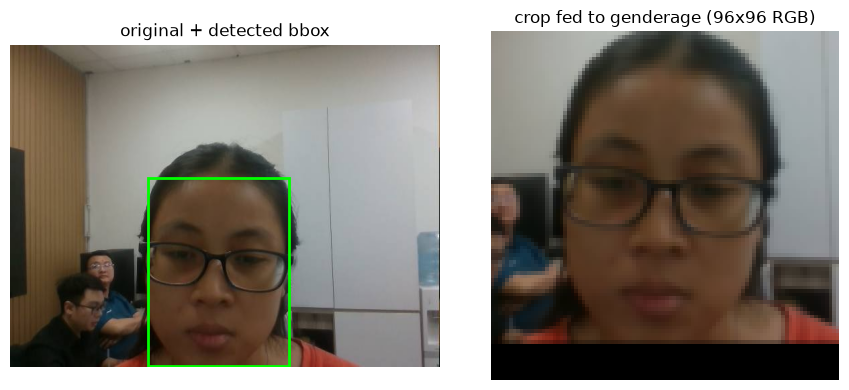

In [147]:
# ---- Debug: inspect raw genderage output and crop ----
import matplotlib.pyplot as plt
import matplotlib.patches as _pat

_dbg_img = cv2.imread(img_paths[1])
_dbg_det = run_face_detect(_dbg_img, face_det_qnn)
print(f"image : {os.path.basename(img_paths[0])}  ({_dbg_img.shape[1]}x{_dbg_img.shape[0]})")
print(f"faces : {len(_dbg_det)}")

if _dbg_det:
    _xyxy, _score, _lm = _dbg_det[0]
    w = _xyxy[2] - _xyxy[0]; h = _xyxy[3] - _xyxy[1]
    print(f"bbox  : {[round(v,1) for v in _xyxy]}  score={_score:.3f}  size={w:.0f}x{h:.0f}")

    _blob = preprocess_insightface(_dbg_img, _xyxy)
    print(f"\nblob  : shape={_blob.shape}  dtype={_blob.dtype}")
    print(f"blob  : min={_blob.min():.1f}  max={_blob.max():.1f}  mean={_blob.mean():.1f}  (raw [0,255])")

    _raw = genderage_session.run([ga_output_name], {ga_input_name: _blob})
    _pred = _raw[0][0]
    print(f"\npred shape : {_pred.shape}")
    print(f"pred       : {_pred}")
    print(f"pred[0] female logit : {_pred[0]:.4f}")
    print(f"pred[1] male logit   : {_pred[1]:.4f}")
    print(f"pred[2] age_norm     : {_pred[2]:.4f}  -> age = {_pred[2]*100:.1f}")
    print(f"gender               : {'Female' if _pred[0] > _pred[1] else 'Male'}")

    # crop is in [0,255] float RGB -> clip and convert to uint8 for display
    _crop_rgb = _blob[0].transpose(1, 2, 0).clip(0, 255).astype(np.uint8)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(cv2.cvtColor(_dbg_img, cv2.COLOR_BGR2RGB))
    x1, y1, x2, y2 = _xyxy
    axes[0].add_patch(_pat.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none'))
    axes[0].set_title("original + detected bbox"); axes[0].axis("off")
    axes[1].imshow(_crop_rgb)
    axes[1].set_title("crop fed to genderage (96x96 RGB)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No faces detected")

In [148]:
insightface_age_labels = []
insightface_gender_labels = []
insightface_age_predicts = []
insightface_gender_predicts = []
infer_times = []
kept_paths = []
t_wall_start = time.perf_counter()

for path, age_label, gender_label in tqdm.tqdm(
    zip(img_paths, age_labels, gender_labels), total=len(img_paths)
):
    img = cv2.imread(path)
    face_det = run_face_detect(img, face_det_qnn)
    if not face_det:
        print(f"Invalid number of faces in {path}, skipping.")
        continue
    xyxy, score, landmark = face_det[0]
    blob = preprocess_insightface(img, xyxy)

    t0 = time.perf_counter()
    pred = genderage_session.run([ga_output_name], {ga_input_name: blob})[0][0]
    t1 = time.perf_counter()

    # output [3]: [female_logit, male_logit, age_normalized]
    insightface_gender_predicts.append(int(np.argmax(pred[:2])))   # 0=Female, 1=Male
    insightface_age_predicts.append(int(np.round(pred[2] * 100)))
    insightface_age_labels.append(age_label)
    insightface_gender_labels.append(gender_label)
    infer_times.append((t1 - t0) * 1000.0)
    kept_paths.append(path)

t_wall_end = time.perf_counter()
infer_times = np.array(infer_times)
n = len(infer_times)
wall_s = t_wall_end - t_wall_start

100%|██████████| 8/8 [00:00<00:00, 32.05it/s]


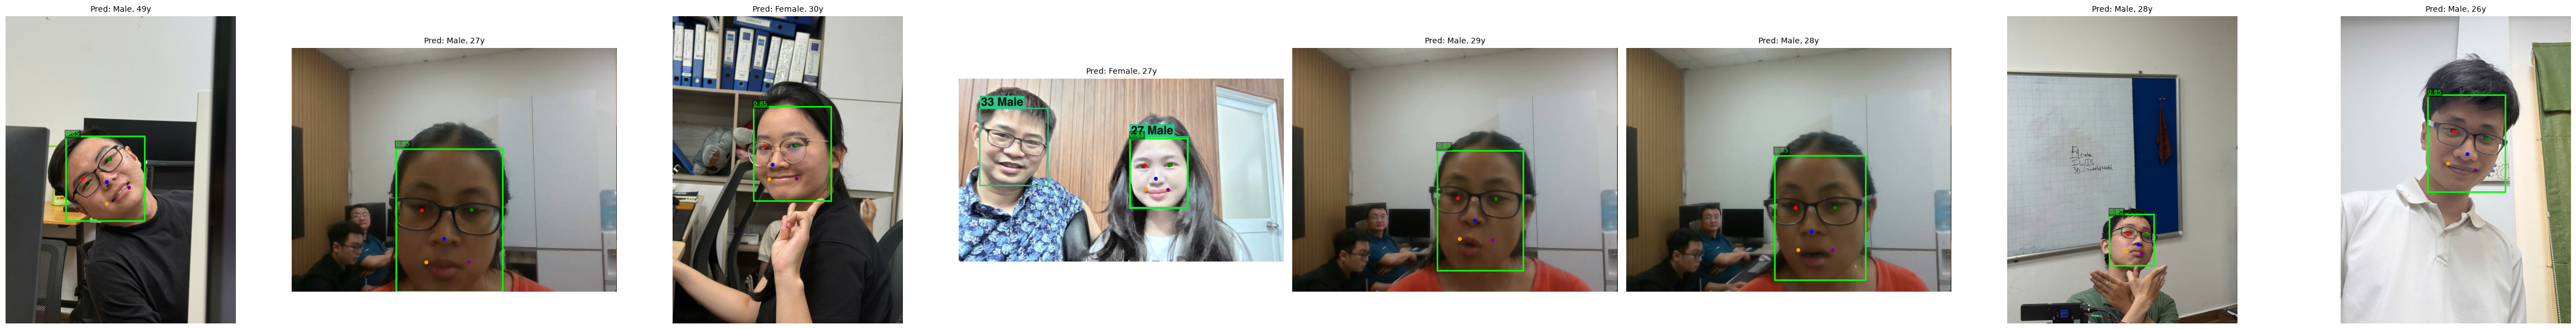

In [124]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

GENDER_NAMES = {0: "Female", 1: "Male"}
LANDMARK_COLORS = ["red", "green", "blue", "orange", "purple"]

n_imgs = len(kept_paths)
fig, axes = plt.subplots(1, n_imgs, figsize=(6 * n_imgs, 6))
if n_imgs == 1:
    axes = [axes]

for ax, path, age_pred, gender_pred, age_true, gender_true in zip(
    axes, kept_paths,
    insightface_age_predicts, insightface_gender_predicts,
    insightface_age_labels, insightface_gender_labels,
):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    det = run_face_detect(img_bgr, face_det_qnn)
    if det:
        xyxy, score, landmark = det[0]
        x1, y1, x2, y2 = xyxy
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 6, f"{score:.2f}", color="lime", fontsize=8,
                bbox=dict(facecolor="black", alpha=0.4, pad=1))

        for (lx, ly), color in zip(landmark, LANDMARK_COLORS):
            ax.plot(lx, ly, "o", color=color, markersize=4)

    label = (
        f"Pred: {GENDER_NAMES[gender_pred]}, {age_pred}y"
        # f"True: {GENDER_NAMES[gender_true]}, {age_true}y"
    )
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [125]:
print(f"samples              : {n}")
print(f"latency mean   (ms)  : {infer_times.mean():.3f}")
print(f"latency min/max(ms)  : {infer_times.min():.3f} / {infer_times.max():.3f}")

single_stream_fps = 1000.0 / infer_times.mean()
e2e_fps = n / wall_s
print(f"single-stream FPS    : {single_stream_fps:.2f}  (1000 / mean infer latency)")
print(f"Pipeline FPS         : {e2e_fps:.2f}  (decode+preprocess+infer+post over wall time)")

preds_age = np.array(insightface_age_predicts, dtype=np.float64)
labels_age = np.array(insightface_age_labels, dtype=np.float64)
err = preds_age - labels_age
abs_err = np.abs(err)
print(f"\nAge:")
print(f"  MAE                : {abs_err.mean():.3f}")
print(f"  RMSE               : {np.sqrt((err**2).mean()):.3f}")

preds_g = np.array(insightface_gender_predicts)
labels_g = np.array(insightface_gender_labels)
print(f"\nGender:")
print(f"  Accuracy           : {accuracy_score(labels_g, preds_g):.4f}")

samples              : 8
latency mean   (ms)  : 0.712
latency min/max(ms)  : 0.591 / 0.919
single-stream FPS    : 1403.88  (1000 / mean infer latency)
Pipeline FPS         : 36.80  (decode+preprocess+infer+post over wall time)

Age:
  MAE                : 7597724.500
  RMSE               : 12407023.173

Gender:
  Accuracy           : 0.7500


# Gender Predict

In [28]:
MARGIN_RATE = 0.

## ONNX

In [29]:
gender_session = ort.InferenceSession("models/gender.onnx")
input_name = gender_session.get_inputs()[0].name
output_name = gender_session.get_outputs()[0].name

In [30]:
# Warm up
dummy = np.random.rand(224, 224, 3).astype(np.float32)
test = gender_session.run([output_name], {input_name: preprocess(dummy)})

In [31]:
np.sum(test[0]) 

np.float32(1.0)

In [32]:
test[0]

array([[0.49551222, 0.50448775]], dtype=float32)

In [33]:
correct_gender_labels = []
gender_predicts = []
infer_times = []  # pure inference latency, per sample (ms)
kept_paths = []
t_wall_start = time.perf_counter()
for path, gender_label in tqdm.tqdm(zip(img_paths, gender_labels)):
    img = cv2.imread(path)
    face_det = run_face_detect(img, face_det_qnn)
    if face_det is None or len(face_det) == 0:
        print(f"Invalid number of faces in {path}, skipping.")
        continue
    xyxy, score, landmark = face_det[0]   # first detected face: (bbox, score, landmark5)
    input_data = preprocess_face_crop(img, xyxy, landmark, margin=MARGIN_RATE)

    t0 = time.perf_counter()
    output = gender_session.run([output_name], {input_name: input_data})
    t1 = time.perf_counter()

    infer_times.append((t1 - t0) * 1000.0)
    gender_predicts.append(postprocess_gender(output))
    correct_gender_labels.append(gender_label)
    kept_paths.append(path)
t_wall_end = time.perf_counter()

infer_times = np.array(infer_times)
n = len(infer_times)
wall_s = t_wall_end - t_wall_start

9it [00:04,  2.19it/s]

Invalid number of faces in /home/ubuntu/AgeDB/758_WEBDuBois_30_m.jpg, skipping.


123it [00:54,  2.23it/s]

Invalid number of faces in /home/ubuntu/AgeDB/8261_ReginaldOwen_75_m.jpg, skipping.


204it [01:30,  2.08it/s]

Invalid number of faces in /home/ubuntu/AgeDB/37_EsteeLauder_65_f.jpg, skipping.


500it [03:48,  2.19it/s]


In [34]:
# Inference-only latency (industry standard: time inference call, report percentiles)
print(f"samples              : {n}")
print(f"latency mean   (ms)  : {infer_times.mean():.3f}")
print(f"latency min/max(ms)  : {infer_times.min():.3f} / {infer_times.max():.3f}")

# Throughput
single_stream_fps = 1000.0 / infer_times.mean()   # latency-bound (inference only)
e2e_fps = n / wall_s                               # end-to-end incl. imread+preprocess+post
print(f"single-stream FPS    : {single_stream_fps:.2f}  (1000 / mean infer latency)")
print(f"Pipeline FPS    : {e2e_fps:.2f}  (decode+preprocess+infer+post over wall time)")

preds = np.array(gender_predicts, dtype=np.float64)
labels = np.array(correct_gender_labels, dtype=np.float64)
acc = accuracy_score(labels, preds)
print(f"Accuracy           : {acc:.4f}")

samples              : 497
latency mean   (ms)  : 445.134
latency min/max(ms)  : 363.932 / 658.376
single-stream FPS    : 2.25  (1000 / mean infer latency)
Pipeline FPS    : 2.18  (decode+preprocess+infer+post over wall time)
Accuracy           : 0.9577


## QNN

In [35]:
class GenderDetectQNN(QNNContext):
    def Inference(self, input_data):
        return super().Inference([input_data])

gender_qnn = GenderDetectQNN("gender", "models/gender.bin")

In [36]:
# Warm up
dummy = np.random.rand(224, 224, 3).astype(np.float32)
gender_qnn.Inference(preprocess(dummy))

[array([[0.49462894, 0.503418  ]], dtype=float32)]

In [37]:
correct_gender_labels = []
gender_predicts = []
infer_times = []  # pure inference latency, per sample (ms)
kept_paths = []
t_wall_start = time.perf_counter()
for path, gender_label in tqdm.tqdm(zip(img_paths, gender_labels)):
    img = cv2.imread(path)
    face_det = run_face_detect(img, face_det_qnn)
    if face_det is None or len(face_det) == 0:
        print(f"Invalid number of faces in {path}, skipping.")
        continue
    
    xyxy, score, landmark = face_det[0]   # first detected face: (bbox, score, landmark5)
    input_data = preprocess_face_crop(img, xyxy, landmark, margin=MARGIN_RATE)

    t0 = time.perf_counter()
    output = bursted_inference(gender_qnn, input_data)
    t1 = time.perf_counter()

    infer_times.append((t1 - t0) * 1000.0)
    gender_predicts.append(postprocess_gender(output))
    correct_gender_labels.append(gender_label)
    kept_paths.append(path)
t_wall_end = time.perf_counter()

infer_times = np.array(infer_times)
n = len(infer_times)
wall_s = t_wall_end - t_wall_start

14it [00:00, 43.47it/s]

Invalid number of faces in /home/ubuntu/AgeDB/758_WEBDuBois_30_m.jpg, skipping.


131it [00:03, 42.00it/s]

Invalid number of faces in /home/ubuntu/AgeDB/8261_ReginaldOwen_75_m.jpg, skipping.


211it [00:05, 42.42it/s]

Invalid number of faces in /home/ubuntu/AgeDB/37_EsteeLauder_65_f.jpg, skipping.


500it [00:12, 40.41it/s]


In [38]:
# Inference-only latency (industry standard: time inference call, report percentiles)
print(f"samples              : {n}")
print(f"latency mean   (ms)  : {infer_times.mean():.3f}")
print(f"latency min/max(ms)  : {infer_times.min():.3f} / {infer_times.max():.3f}")

# Throughput
single_stream_fps = 1000.0 / infer_times.mean()   # latency-bound (inference only)
e2e_fps = n / wall_s                               # end-to-end incl. imread+preprocess+post
print(f"single-stream FPS    : {single_stream_fps:.2f}  (1000 / mean infer latency)")
print(f"Pipeline FPS    : {e2e_fps:.2f}  (decode+preprocess+infer+post over wall time)")

preds = np.array(gender_predicts, dtype=np.float64)
labels = np.array(correct_gender_labels, dtype=np.float64)
acc = accuracy_score(labels, preds)
print(f"Accuracy           : {acc:.4f}")

samples              : 497
latency mean   (ms)  : 13.248
latency min/max(ms)  : 12.165 / 16.422
single-stream FPS    : 75.48  (1000 / mean infer latency)
Pipeline FPS    : 40.15  (decode+preprocess+infer+post over wall time)
Accuracy           : 0.9577


In [40]:
if face_det is not None:
    del face_det
    face_det = None

# if age_qnn is not None:
#     del age_qnn
#     age_qnn = None

if gender_qnn is not None:
    del gender_qnn
    gender_qnn = None

## Insightface ONNX

In [ ]:
# insightface_gender_predicts / insightface_gender_labels collected in Age Predict > Insightface ONNX
preds_g = np.array(insightface_gender_predicts)
labels_g = np.array(insightface_gender_labels)
print(f"samples              : {len(preds_g)}")
print(f"Accuracy             : {accuracy_score(labels_g, preds_g):.4f}")

# Age calibration fit

IMDB-WIKI age model mean-reverts toward ~25-35: elderly under-predicted,
young (esp. young female) over-predicted. The error is **proportional** (grows
with distance from the center), so a flat `+5` offset barely helps. Fit a
per-gender affine map `true ≈ a*pred + b` by least squares on AgeDB.

Equivalent pivot/gain stretch: `gain = a`, `pivot = b / (1 - a)`.
Paste the printed coeffs into `app/utils.py` `calibrate_age`.

In [ ]:
# Collect raw age predictions + true age/gender on AgeDB (onnx age model).
# Uses face_det_qnn + age_session (both still loaded above).
MARGIN_RATE = 0.

age_session = ort.InferenceSession("models/age.onnx")
age_in = age_session.get_inputs()[0].name
age_out = age_session.get_outputs()[0].name

fit_pred, fit_true_age, fit_true_gender = [], [], []
for path, age_label, gender_label in tqdm.tqdm(
    zip(img_paths, age_labels, gender_labels), total=len(img_paths)
):
    img = cv2.imread(path)
    det = run_face_detect(img, face_det_qnn)
    if not det:
        continue
    xyxy, score, landmark = det[0]
    inp = preprocess_face_crop(img, xyxy, landmark, margin=MARGIN_RATE)
    out = age_session.run([age_out], {age_in: inp})
    fit_pred.append(postprocess_age(out))
    fit_true_age.append(age_label)
    fit_true_gender.append(gender_label)  # 0=Female, 1=Male

fit_pred = np.array(fit_pred, dtype=np.float64)
fit_true_age = np.array(fit_true_age, dtype=np.float64)
fit_true_gender = np.array(fit_true_gender, dtype=np.int64)
print("collected", len(fit_pred), "samples")

In [ ]:
# Fit per-gender affine calibration  true ~ a*pred + b  (least squares).
def fit_affine(p, t):
    A = np.vstack([p, np.ones_like(p)]).T
    a, b = np.linalg.lstsq(A, t, rcond=None)[0]
    return float(a), float(b)

def mae(p, t):
    return float(np.mean(np.abs(p - t)))

def report(tag, p, t):
    a, b = fit_affine(p, t)
    cal = a * p + t * 0 + b
    pivot = b / (1 - a) if abs(1 - a) > 1e-6 else float("nan")
    print(f"{tag:8} n={len(p):3d}  a={a:.4f} b={b:+.4f}  "
          f"(gain={a:.3f} pivot={pivot:.1f})  "
          f"MAE {mae(p, t):.2f} -> {mae(cal, t):.2f}")
    return a, b

print("                                   raw -> calibrated")
report("ALL", fit_pred, fit_true_age)

AGE_CALIB = {}
for g, name in [(0, "Female"), (1, "Male")]:
    m = fit_true_gender == g
    if m.sum() < 2:
        continue
    a, b = report(name, fit_pred[m], fit_true_age[m])
    AGE_CALIB[name] = (round(a, 4), round(b, 4))

print("\n# paste into app/utils.py")
print("AGE_CALIB =", AGE_CALIB)

# Sanity: per-decile residual (mean err = pred - true) to confirm the slope shape.
print("\npred-age decile | mean_pred mean_true mean_err  n")
edges = np.percentile(fit_pred, np.arange(0, 101, 10))
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (fit_pred >= lo) & (fit_pred <= hi)
    if m.sum() == 0:
        continue
    print(f"  [{lo:5.1f},{hi:5.1f}] | {fit_pred[m].mean():8.1f} "
          f"{fit_true_age[m].mean():8.1f} {(fit_pred[m]-fit_true_age[m]).mean():+8.1f}  {m.sum():3d}")

# Gender threshold debias

IMDB-WIKI is male-skewed, so the model's boundary leans Male (real-world: girls
called "Male"). Instead of argmax, predict Female when `p(Female) >= τ`. Sweep τ
to maximize **balanced accuracy** (mean of per-class recall) — that's what
fixes the minority (Female) class, unlike plain accuracy which a male-skewed set
rewards for guessing Male. Paste the best τ into `GENDER_FEMALE_THRESHOLD`.

In [ ]:
# Collect p(Female) + true gender, sweep the Female threshold.
gender_session = ort.InferenceSession("models/gender.onnx")
g_in = gender_session.get_inputs()[0].name
g_out = gender_session.get_outputs()[0].name

p_female, g_true = [], []
for path, gender_label in tqdm.tqdm(zip(img_paths, gender_labels), total=len(img_paths)):
    img = cv2.imread(path)
    det = run_face_detect(img, face_det_qnn)
    if not det:
        continue
    xyxy, score, landmark = det[0]
    inp = preprocess_face_crop(img, xyxy, landmark, margin=0.)
    out = gender_session.run([g_out], {g_in: inp})[0]
    p_female.append(float(out[0][0]))   # index 0 = Female
    g_true.append(gender_label)         # 0=Female, 1=Male

p_female = np.array(p_female)
g_true = np.array(g_true)               # 0=F, 1=M
is_f = g_true == 0
print(f"n={len(g_true)}  Female={is_f.sum()}  Male={(~is_f).sum()}  "
      f"(prior skew Female={is_f.mean():.2%})")

print("\n  tau | acc  bal_acc  F_recall  M_recall  F_called")
best = (-1, 0.5)
for tau in np.arange(0.20, 0.81, 0.05):
    pred_f = p_female >= tau                 # True -> Female
    acc = np.mean(pred_f == is_f)
    f_rec = np.mean(pred_f[is_f]) if is_f.any() else 0.0          # recall Female
    m_rec = np.mean(~pred_f[~is_f]) if (~is_f).any() else 0.0     # recall Male
    bal = 0.5 * (f_rec + m_rec)
    print(f"  {tau:.2f}| {acc:.3f}  {bal:.3f}    {f_rec:.3f}     {m_rec:.3f}     {pred_f.mean():.2%}")
    if bal > best[0]:
        best = (bal, round(float(tau), 2))

print(f"\nbest balanced-acc tau = {best[1]}  (bal_acc={best[0]:.3f})")
print("# paste into app/inference.py / docker-compose env")
print(f"GENDER_FEMALE_THRESHOLD = {best[1]}")